# 🛠️ 角色三任務：資料前處理與進階探索

## 🎯 你的主要任務
1. **全組資料前處理**：讀取原始資料，剔除嚴重缺失的無效數據，統一產出乾淨的 CSV 供大家使用 。
2. **額外 EDA (必做)**：探討小組選定的「行為變數」與「連續變數」之間的交叉關聯 (例如子群組比較)，並產出圖表與解釋 。
3. **成果收斂**：將大家的結果製作成一個「推論總結表格 (Summary Table)」 。
4. **最終排版**：統整所有人的程式碼到最終的 Notebook，並排版佔分 30% 的一頁 PDF 。

## 💾 資料要怎麼處理
* **不可動原始資料**：只能透過程式碼讀取 `data/raw/YRBS_2007.csv`，絕對不可修改原檔 。
* **匯出乾淨資料**：處理完畢後，使用程式碼將 DataFrame 匯出成 `.csv`，並上傳到 GitHub 的 `data/processed/` 資料夾 。

📂 檔案讀取要正確：

Colab 預設沒有我們的資料夾。請大家每次開啟 Colab 時，先在左側資料夾圖示中手動上傳 yrbs_cleaned.csv。

🖼️ 嚴禁螢幕截圖，圖表必須存檔：

我們不能用截圖產圖，畫出來的每一張圖，請用程式碼存檔 。

☁️ 下載雲端產物：

Colab 關閉後，裡面存的圖片和表格就會消失。只要程式有存出圖片或 csv 表格，請立刻從 Colab 左側列表下載到自己的電腦裡。

🔄 每日手動備份到 GitHub ：

每次寫完一個段落準備關掉 Colab 前，請做這兩件事：點擊 Colab 左上角「檔案」 $\rightarrow$ 「下載 .ipynb」到我們的 GitHub 網頁，把 .ipynb 檔上傳到 notebooks/ 資料夾；把圖片檔上傳到 outputs/figures/ 資料夾。

圖表已儲存為 'extra_eda_1_kde.png'。


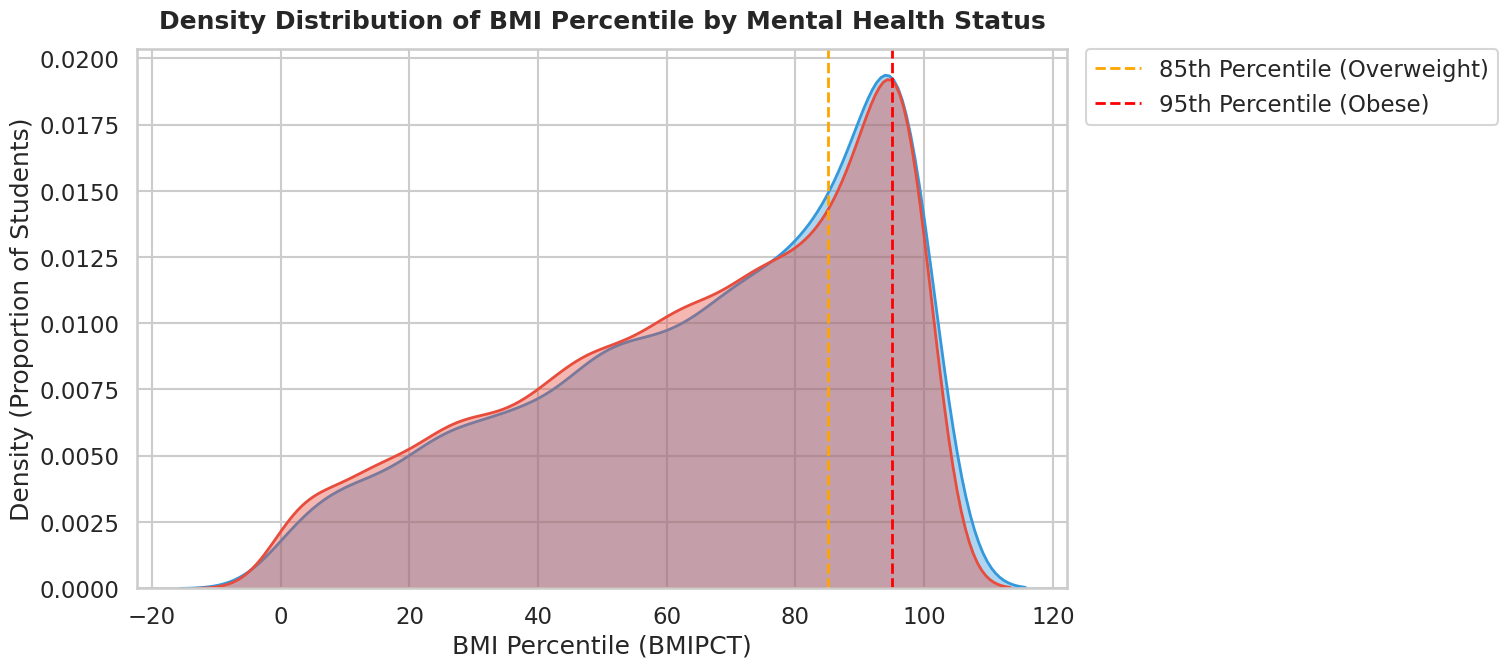

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==========================================
# 1. 讀取資料與基礎設定 / Read and Setup Data
# ==========================================
file_name = 'yrbs_cleaned.csv'
df = pd.read_csv(file_name)

# 將 1/0 轉為文字供圖表圖例使用 / Convert 1/0 to text for legend
df['Mental_Status'] = df['SadOrHopeless_Recoded'].map({
    1: 'Risk Group (Sad/Hopeless)',
    0: 'Normal Group'
})
# 將性別代碼轉為文字 / Convert sex codes to text
df['Sex_Label'] = df['WhatIsYourSex'].map({1: 'Female', 2: 'Male'})

# ==========================================
# 2. 圖表一：尋找壓力臨界值 (KDE 密度圖)
# Plot 1: Finding the Stress Threshold (KDE Plot)
# ==========================================
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid", context="talk")

# 繪製獨立面積的密度圖 / Plot KDE with independent normalization
sns.kdeplot(
    data=df,
    x='BMIPCT',
    hue='Mental_Status',
    fill=True,
    alpha=0.4,
    linewidth=2,
    palette=['#e74c3c', '#3498db'],
    common_norm=False
)

# 加入 CDC 體重標準參考線 / Add CDC weight standard reference lines
plt.axvline(85, color='orange', linestyle='--', linewidth=2, label='85th Percentile (Overweight)')
plt.axvline(95, color='red', linestyle='--', linewidth=2, label='95th Percentile (Obese)')

# 設定純英文標籤避免亂碼 / Set pure English labels to avoid rendering issues
plt.title('Density Distribution of BMI Percentile by Mental Health Status', fontweight='bold', pad=15)
plt.xlabel('BMI Percentile (BMIPCT)')
plt.ylabel('Density (Proportion of Students)')
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0.)

output_img1 = 'extra_eda_1_kde.png'
plt.savefig(output_img1, dpi=300, bbox_inches='tight')
print(f"圖表已儲存為 '{output_img1}'。")
plt.show()

這張圖比較了「憂鬱學生（紅線）」與「正常學生（藍線）」在不同 BMI 百分位數的分佈密度。

This plot compares the BMI percentile distribution between "Risk Group (red line)" and "Normal Group (blue line)".

在正常體重範圍內，兩條線高度重疊；但當 BMI 突破 85（過重基準線）後，紅線的密度明顯高於藍線。這顯示「過重」可能是一個引發心理壓力的臨界點。

In the healthy weight range, the two curves overlap significantly. However, once the BMI crosses the 85th percentile (Overweight threshold), the red curve becomes denser than the blue curve. This indicates that being overweight might act as a critical threshold for psychological stress.